# Controlled Trajectory Examples: 1 — Double Integrator

This is the **first example** in a four-part progression of controlled-trajectory
benchmarks built with `CellularSheaves.jl`:

1. **Double integrator** (this page) — the canonical first LQR system.
2. **Vehicle platoon** — same control story in a multi-agent / path-graph setting.
3. **Planar quadrotor** — a more realistic multi-input robotic system.
4. **Mass-spring-damper chain** — graph-coupled mechanical system bridging
   toward later consensus and network examples.

Each example follows the same conceptual pipeline:

$$
(A_c, B_c)
\;\longrightarrow\;
(A_d, B_d)
\;\longrightarrow\;
\mathcal{T}(x_1, x_{k+1})
\;\longrightarrow\;
\min_{z \in \mathcal{T}(x_1, x_{k+1})} J(z).
$$

## Physical system

A unit point mass moves along a line.  The state is position and velocity;
the control input is acceleration:

$$
x = \begin{bmatrix} p \\ \dot{p} \end{bmatrix}, \qquad u = a,
\qquad
A_c = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix},
\qquad
B_c = \begin{bmatrix} 0 \\ 1 \end{bmatrix}.
$$

Despite its simplicity this system exhibits every feature of the
controlled-trajectory workflow and serves as the natural reference point for
the rest of the progression.

**References:**
- Anderson, B. D. O. & Moore, J. B. (1990). *Optimal Control: Linear Quadratic
  Methods*. Prentice-Hall.
- Lewis, F. L., Vrabie, D. L., & Syrmos, V. L. (2012). *Optimal Control*, 3rd ed.
  John Wiley & Sons. ISBN 978-0-470-63349-6.

In [1]:
using CellularSheaves
using LinearAlgebra
using BlockArrays
using Plots
using SparseArrays

## Step 1: Define the continuous-time model

The double integrator in standard state-space form.

In [2]:
Ac = [0.0  1.0;
      0.0  0.0]
Bc = reshape([0.0, 1.0], 2, 1)

2×1 Matrix{Float64}:
 0.0
 1.0

## Step 2: Discretize with zero-order hold

A `ControlledTrajectorySheaf` wraps the ZOH discretization
$x_{t+1} = A_d x_t + B_d u_t$ as a path-graph sheaf.  Its global
sections are exactly the feasible sampled state-control trajectories.

In [3]:
h = 0.25   # sample period (seconds)
k = 8      # number of time steps

F  = EuclideanSheaf{Float64}(fill(2, 1))   # base sheaf: one vertex, 2D stalk
ts = ControlledTrajectorySheaf(F, Ac, Bc, h, k)

println("State dimension  n = ", ts.state_dim)
println("Control dimension m = ", ts.control_dim)
println("Steps             k = ", ts.k)

State dimension  n = 2
Control dimension m = 1
Steps             k = 8


## Step 3: Fix endpoint states

We start at rest and aim to reach a target position with zero velocity.

In [4]:
x1  = [0.0, 0.0]   # initial state:  position 0, velocity 0
xk1 = [1.0, 0.0]   # terminal state: position 1, velocity 0

2-element Vector{Float64}:
 1.0
 0.0

## Step 4: Build the feasible trajectory affine space

`feasible_control_trajectory_basis` returns:
- `z_p` — a particular feasible trajectory (the harmonic extension of the
  boundary data);
- `N`   — columns spanning all endpoint-preserving perturbations.

Any feasible trajectory satisfies $z = z_p + N \alpha$ for some
$\alpha \in \mathbb{R}^r$.

In [5]:
z_p_raw, N = feasible_control_trajectory_basis(ts, x1, xk1)

n = ts.state_dim
m = ts.control_dim
r = size(N, 2)
println("Trajectory dimension p = ", (k+1)*n + k*m)
println("Free parameters      r = ", r)

Trajectory dimension p = 26
Free parameters      r = 6


## Step 5: Assemble the LQR objective

We minimize the quadratic running cost

$$
J(z) = \tfrac{1}{2} \sum_{t=1}^{k}
  \bigl( x_t^\top Q\, x_t + u_t^\top R_u\, u_t \bigr)
  + \tfrac{1}{2}\, x_{k+1}^\top Q_f\, x_{k+1}.
$$

The assembled cost Hessian $H$ is block-diagonal: $k$ copies of $Q$
on the running state blocks, $Q_f$ on the terminal block, and $k$ copies
of $R_u$ on the control blocks.

In [6]:
Q  = Matrix{Float64}(I, n, n)
Ru = Matrix{Float64}(I, m, m)
Qf = 10.0 * Matrix{Float64}(I, n, n)   # heavier terminal penalty

H, f, _ = lqr_objective(ts, Q, Ru; Qf=Qf)

(sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  17, 18, 19, 20, 21, 22, 23, 24, 25, 26], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  17, 18, 19, 20, 21, 22, 23, 24, 25, 26], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  10.0, 10.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 26, 26), [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0  …  -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0], 0.0)

Rows/columns are ordered: [x₁, x₂, …, x_{k+1}, u₁, …, u_k].
The state blocks (left upper) carry Q and Qf; the control blocks (lower right) carry Ru.

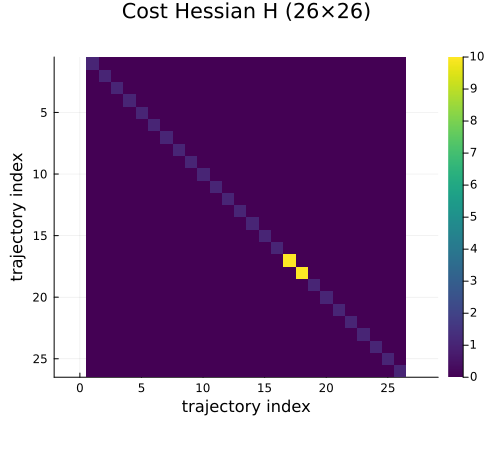

In [7]:
p_H = heatmap(Matrix(H);
    color=:viridis, colorbar=true,
    title="Cost Hessian H ($(size(H,1))×$(size(H,2)))",
    xlabel="trajectory index", ylabel="trajectory index",
    yflip=true, aspect_ratio=:equal, size=(500, 450))
p_H

## Step 6: Solve for the optimal feasible trajectory

`optimal_control_trajectory` restricts the quadratic objective to
the feasible affine space and solves the reduced quadratic programme

$$
\min_{\alpha} \tfrac{1}{2}\, \alpha^\top (N^\top H N)\, \alpha
  + \alpha^\top N^\top (H z_p + f).
$$

In [8]:
z_opt, α_opt, z_p_block, null_basis =
    optimal_control_trajectory(ts, x1, xk1, H, f)

([0.0, 0.0, 0.040399563957539686, 0.3231965116603204, 0.14930676160293496, 0.5480610695028425, 0.3037100987563254, 0.6871656277242811, 0.4828139305958494, 0.7456650269919127  …  1.0, 0.0, 1.292786046641284, 0.8994582313700901, 0.5564182328857552, 0.23399759707052703, -0.09837706484502372, -0.47280560064661686, -0.9235908715920615, -1.4878865708839477], [-0.47280560064661686, -0.09837706484502372, 0.23399759707052703, 0.5564182328857552, 0.8994582313700901, 1.292786046641284], [0.0, 0.0, -6.696032617270492e-16, -8.465450562766835e-16, -1.15879528195251e-15, -1.1657341758564165e-15, -1.727784582072904e-15, -1.415534356397077e-15, -2.359223927328463e-15, -1.595945597898665e-15  …  1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.000000000000078, -16.00000000000007], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; -2.0000000000000004 -3.0000000000000018 … -6.000000000000008 -7.000000000000016; 1.0000000000000004 2.0000000000000018 … 5.000000000000009 6.000000000000015])

Verify first-order optimality: the reduced gradient should vanish at α*.

In [9]:
Rred = null_basis' * H * null_basis
rred = null_basis' * (H * Array(z_p_block) + f)
println("Optimality residual ‖Rred α* + rred‖ = ", norm(Rred * α_opt + rred))

Optimality residual ‖Rred α* + rred‖ = 7.105427357601002e-15


Verify that z_opt lies in the feasible affine space.

In [10]:
println("Affine-space error ‖z_opt − (z_p + N α*)‖ = ",
        norm(Array(z_opt) - (Array(z_p_block) + null_basis * α_opt)))

Affine-space error ‖z_opt − (z_p + N α*)‖ = 0.0


## Step 7: Plot the optimal trajectory

State blocks: `z_opt[Block(t)]` for `t = 1, …, k+1`.
Control blocks: `z_opt[Block(k+1+t)]` for `t = 1, …, k`.

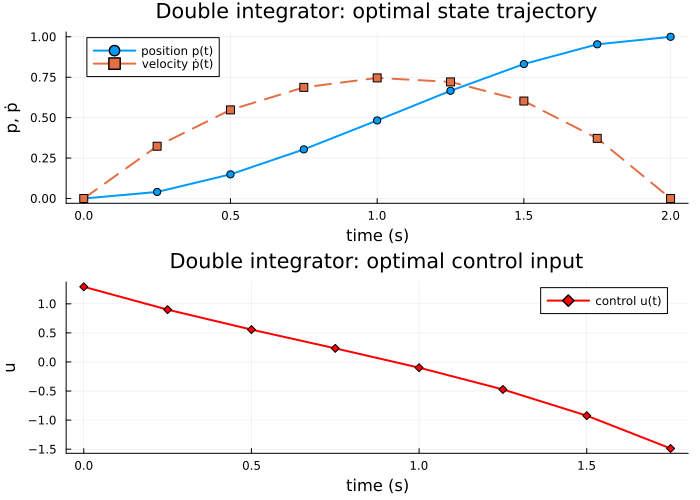

In [11]:
times_state   = h .* (0:k)
times_control = h .* (0:k-1)

positions  = [Array(z_opt[Block(t)])[1] for t in 1:k+1]
velocities = [Array(z_opt[Block(t)])[2] for t in 1:k+1]
controls   = [Array(z_opt[Block(k+1+t)])[1] for t in 1:k]

p_pos = plot(times_state, positions;
    lw=2, marker=:circle, label="position p(t)",
    xlabel="time (s)", ylabel="p, ṗ",
    title="Double integrator: optimal state trajectory")
plot!(p_pos, times_state, velocities;
    lw=2, marker=:square, linestyle=:dash, label="velocity ṗ(t)")

p_ctrl = plot(times_control, controls;
    lw=2, marker=:diamond, color=:red, label="control u(t)",
    xlabel="time (s)", ylabel="u",
    title="Double integrator: optimal control input")

di_plot = plot(p_pos, p_ctrl; layout=(2, 1), size=(700, 500))
di_plot

## Verification

Check that both endpoint conditions are satisfied and that the discrete
dynamics $x_{t+1} = A_d x_t + B_d u_t$ hold at every step.

In [12]:
@assert Array(z_opt[Block(1)])     ≈ x1  "Initial state not satisfied"
@assert Array(z_opt[Block(k + 1)]) ≈ xk1 "Terminal state not satisfied"

for t in 1:k
    xt  = Array(z_opt[Block(t)])
    xt1 = Array(z_opt[Block(t + 1)])
    ut  = Array(z_opt[Block(k + 1 + t)])
    @assert norm(ts.Ad * xt + ts.Bd * ut - xt1) < 1e-10 "Dynamics violated at step $t"
end
println("All endpoint and dynamics constraints satisfied.")

All endpoint and dynamics constraints satisfied.


## Relationship to the sheaf boundary-value problem

The particular solution `z_p` is the **harmonic extension** of the boundary
data $(x_1, x_{k+1})$ to the full trajectory space.  It minimises the
sheaf Laplacian energy (i.e., the squared coboundary $\|dz\|^2$).

The null-basis columns $N_j$ are the *global sections of the controlled
sheaf* after zeroing the two boundary vertices — exactly the
endpoint-preserving degrees of freedom.

The optimal trajectory lives in the affine space $z_p + N\alpha^*$, where
$\alpha^*$ minimises the LQR cost restricted to that affine space.  The two
viewpoints — sheaf / harmonic-extension and quadratic / LQR — combine cleanly
because the feasible set is a finite-dimensional affine subspace.

## What this example establishes

The double integrator illustrates the complete pipeline in its simplest form.
The next example, **Vehicle Platoon**, keeps the same control story but
scales to a multi-agent setting by stacking two double integrators on a
two-vertex base sheaf, making the connection to network-structured problems
explicit for the first time.